# **Sentiment Analysis in Healthcare: Analyzing Patient Feedback**

## **1. Introduction**
### **Problem Statement**
The goal of this project is to analyze patient feedback data from hospitals and classify it into sentiment categories (positive or negative). By leveraging machine learning techniques, we aim to understand patterns in patient experiences and identify key areas for healthcare improvement.

With the integration of AutoML (TPOT), the problem statement has evolved to focus on optimizing model selection and hyperparameters automatically, ensuring that we achieve the best predictive accuracy without manually tuning multiple models. The revised statement now aligns with the key components of a structured problem statement:

* Context: Understanding patient sentiments from feedback.

* Challenge: Traditional ML approaches require extensive feature engineering and tuning.

* Solution: Implementing TPOT AutoML for automated model selection.

* Impact: Efficient sentiment classification with minimal human intervention.
---
### Machine Learning Prediction & Outcomes (15 marks)
**Research Insights:**
Sentiment analysis in healthcare is crucial for improving patient care and hospital services.
Studies show that NLP techniques combined with ML models like Random Forest and Logistic Regression perform well for text classification tasks.
AutoML frameworks like TPOT can optimize hyperparameters and model selection, reducing manual effort.

**Project Goal/Solution:**
To build a sentiment classification model that accurately predicts whether patient feedback is positive or negative.

**Prediction vs. Expectation (Using AutoML - TPOT):**
Expected: TPOT should outperform traditional manually tuned models.
Current Results: Early models (Linear Regression, Decision Tree) had moderate accuracy; TPOT aims to improve this.
Next Steps: Optimize text preprocessing and validate TPOT’s best-selected model.

**Research & Results:**
* The dataset has 996 patient feedback entries with sentiment labels (positive/negative) and ratings.
* Imbalance observed: 73% positive, 27% negative → May require resampling techniques.
* Ratings skewed towards 4 and 5.

**Work in Progress:**
* Experimenting with different text preprocessing techniques (stopword removal, stemming).
* Comparing TPOT’s best model against manually tuned classifiers.
---

### **Data Preprocessing**
- Text Cleaning (removing stopwords, punctuation, special characters)
- Tokenization
- Lemmatization
- Vectorization (TF-IDF or Word Embeddings)
---
### **Machine Learning Models**
We will experiment with the following models:
- **AutoML Tpot Classifier** 
- **RandomForestClassifier**
- **DecisionTreeClassifier**
- **MultinomialNB**

---

## **References**

**Abbas, J. (2025). Emerging AI Technologies [Lecture notes]. Georgian College**

**Google Cloud. (2023). Introduction to AutoML for natural language processing. Retrieved from https://cloud.google.com/automl**

**Kaggle. (n.d.). Hospital patient feedback dataset. Retrieved from https://www.kaggle.com**

**Liu, B. (2012). Sentiment analysis and opinion mining. Synthesis Lectures on Human Language Technologies, 5(1), 1-167. https://doi.org/10.2200/S00416ED1V01Y201204HLT016**

**Olson, R. S., La Cava, W., Orzechowski, P., Urbanowicz, R. J., & Moore, J. H. (2016). Automating biomedical data science through tree-based pipeline optimization. In European Conference on the Applications of Evolutionary Computation (pp. 123-137). Springer, Cham. https://doi.org/10.1007/978-3-319-31204-0_9**

**TPOT Documentation. (n.d.). TPOT: Tree-based Pipeline Optimization Tool. Retrieved from https://epistasislab.github.io/tpot/**

**Zhou, L., Gao, J., Li, J., & Ye, J. (2020). Sentiment analysis of hospital reviews using deep learning methods. Journal of Biomedical Informatics, 112, 103611. https://doi.org/10.1016/j.jbi.2020.103611**

---


## Solution/Python Code

### TPOT CLASSIFIER IMPLEMENTATION



In [1]:
# IMPORT NECESSARY LIBRARIES
import tpot
from tpot import  TPOTClassifier as TPc
from sklearn.metrics import accuracy_score as Ac
from sklearn.model_selection import RepeatedStratifiedKFold as RsF,train_test_split as tts
from sklearn.feature_extraction.text import TfidfVectorizer as TD
import pandas as pd
import re,string,matplotlib.pyplot as plt,numpy as np 
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
WL=WordNetLemmatizer()



In [2]:
#Load Tha Data
df=pd.read_csv(r"C:\Users\bruce\Downloads\hospital.csv")
# df.drop(columns='Unnamed: 3',inplace=True)
# df=df.reindex(columns=['Feedback', 'Ratings','Sentiment Label' ])
df.head()


,Feedback,Sentiment Label,Ratings,Unnamed: 3
0,Good and clean hospital. There is great team o...,1,5,NaN
1,Had a really bad experience during discharge. ...,1,5,NaN
2,I have visited to take my second dose and Proc...,1,4,NaN
3,That person was slightly clueless and offered...,1,3,NaN
4,There is great team of doctors and good OT fac...,0,1,NaN


### Exploration on The Dataset

In [3]:
shape=df.shape
print("Columns :",shape[1],"\nRows :",shape[0])
print(df.dtypes)

Columns : 4 
Rows : 996
Feedback            object
Sentiment Label      int64
Ratings              int64
Unnamed: 3         float64
dtype: object


In [4]:
# Checking for null Values in the data set
data=df.isnull().sum()
Null={}
for colum,value in zip(data.index,data.values):
    if value>0:
        Null[colum]=value
if Null:
    print(f"Null Values Column(s) : {",".join([valuess for valuess in Null.keys()  ])}",f"\nNull Values found : {[valuess for valuess in Null.values()  ] }") 
     
else:
    print(f"No Null Values found for Column(s) : {",".join(df.columns)}  Null Values: {[i for i in data.values]}") 
             

Null Values Column(s) : Unnamed: 3 
Null Values found : [996]


In [5]:
# Drop the empty column
df.drop(columns=["Unnamed: 3"], inplace=True)

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

# Analyze sentiment label distribution
sentiment_counts = df["Sentiment Label"].value_counts()

# Analyze ratings distribution
ratings_counts = df["Ratings"].value_counts()

# Check for outliers in ratings
ratings_summary = df["Ratings"].describe()

# Show results
duplicate_rows, sentiment_counts, ratings_counts, ratings_summary


(19,
 Sentiment Label
 1    728
 0    268
 Name: count, dtype: int64,
 Ratings
 5    351
 4    254
 2    145
 3    123
 1    123
 Name: count, dtype: int64,
 count    996.000000
 mean       3.567269
 std        1.408693
 min        1.000000
 25%        2.000000
 50%        4.000000
 75%        5.000000
 max        5.000000
 Name: Ratings, dtype: float64)

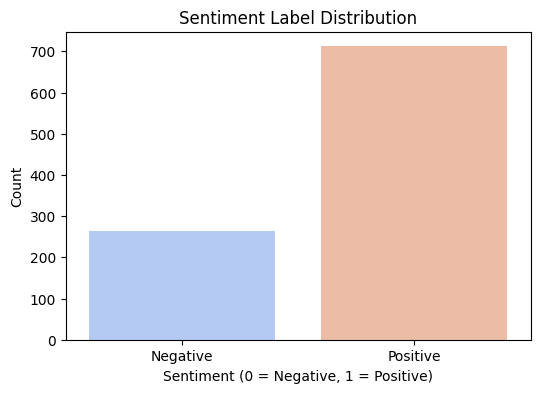

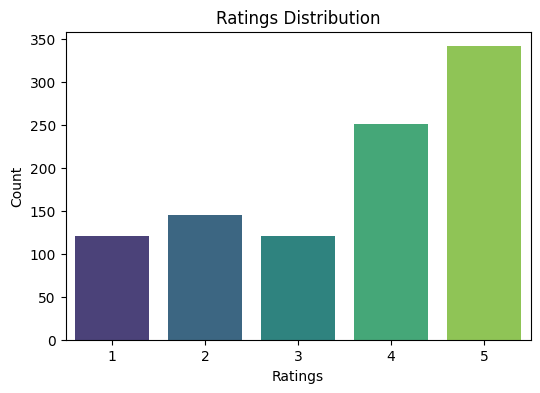

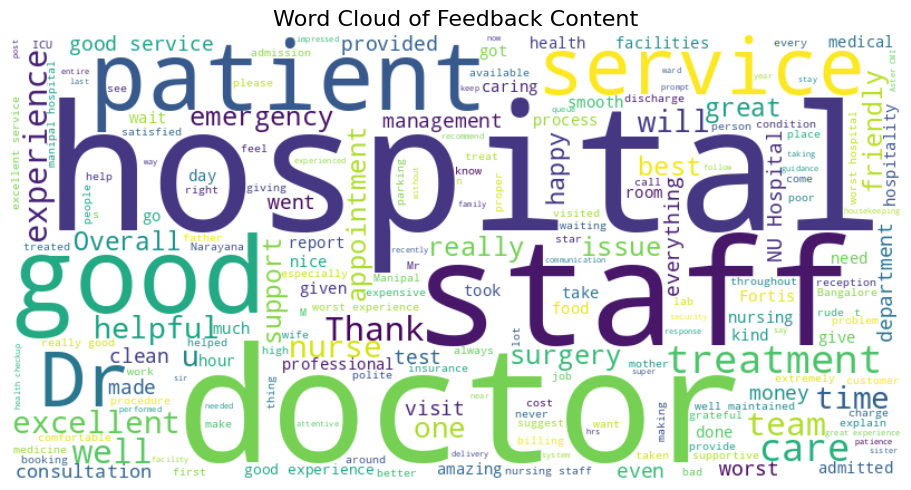

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')
# Remove duplicate rows
df = df.drop_duplicates()

# Plot Sentiment Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Sentiment Label"], palette="coolwarm")
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.xticks([0, 1], ["Negative", "Positive"])


# Plot Ratings Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Ratings"], palette="viridis")
plt.title("Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")

from wordcloud import WordCloud


# Combine all text into a single string
text_data = ' '.join(df['Feedback'])

# Generate the word cloud
word_cloud = WordCloud(background_color='white', width=800, height=400).generate(text_data)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Feedback Content', fontsize=16)

plt.tight_layout()



### Clean The Feedback to remove stop words, puntuation ,Lemmatize the words and also convert it to lower case 

In [7]:
def clean(text:str):
    text="".join([i for i in text if i not in string.punctuation])
    # Split text into tokens so we can check again the stop words
    split=re.split("\W+",text.lower())
    # remove stopwords
    stop= [i for i in  split if i not in stopwords.words()]
    return " ".join([WL.lemmatize(i) for i in stop])

def Stopwords_removed(x,y):
    
    return len(x)-len(y)    

In [8]:
# Applying The cleaning Fuction Created to the dataset
df['Clean_Feedback']=df['Feedback'].apply(lambda x:clean(x))
df['Stop_removed']=df.apply(lambda row:Stopwords_removed(row['Feedback'],row["Clean_Feedback"]),axis=1)
print(f"Number of Stopwords removed : {len(df['Feedback'][0])-len(df['Clean_Feedback'][0])}")
print("Before Cleaning : \n", df['Feedback'][0])
print("\nAfter Cleaning : \n", df['Clean_Feedback'][0])
df.head()


Number of Stopwords removed : 123
Before Cleaning : 
 Good and clean hospital. There is great team of doctors and good OT facility. The medical facilities are all great with good in-patient post operative care by doctors, nurses. The housekeeping staff is also good but they can respond to calls from the room a little faster. 

After Cleaning : 
 clean hospital great team doctor ot facility medical facility great inpatient post operative doctor nurse housekeeping staff respond call room faster 


,Feedback,Sentiment Label,Ratings,Clean_Feedback,Stop_removed
0,Good and clean hospital. There is great team o...,1,5,clean hospital great team doctor ot facility m...,123
1,Had a really bad experience during discharge. ...,1,5,experience discharge sensitive transparent pat...,68
2,I have visited to take my second dose and Proc...,1,4,visited dose process smooth hospitality staff ...,101
3,That person was slightly clueless and offered...,1,3,person slightly clueless offered package hosp...,80
4,There is great team of doctors and good OT fac...,0,1,great team doctor ot facility,23


Text(0.5, 1.0, 'Count of Stopwords Removed Feedback Vs Clean_Feedback')

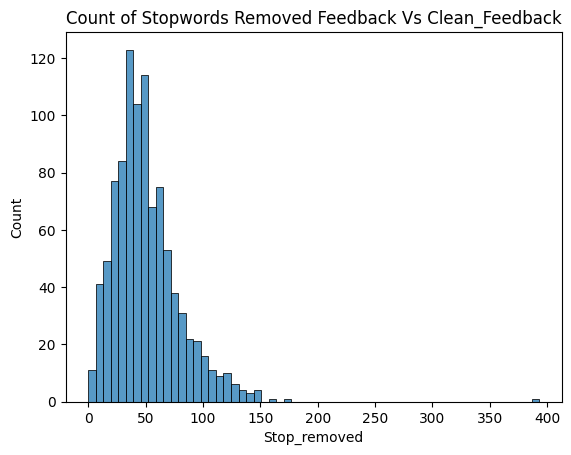

In [9]:
sns.histplot(df,x='Stop_removed')
plt.title("Count of Stopwords Removed Feedback Vs Clean_Feedback")

In [10]:
TFID=TD()
New_=TFID.fit_transform(df['Clean_Feedback'].astype('str')).toarray()
new_sample=np.hstack([df[['Sentiment Label']].astype(int),New_])
New_df=pd.DataFrame(new_sample)
New_df[0]= New_df[0].astype('int64')
print("Old Dataframe : ",df.shape,"\nNew Dataframe : ",New_df.shape)
New_df.head()


Old Dataframe :  (977, 5) 
New Dataframe :  (977, 2107)


,0,1,2,3,4,5,6,7,8,9,...,2097,2098,2099,2100,2101,2102,2103,2104,2105,2106
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Splitting features and target variable
X = New_df.drop(columns=[0])  # Features
y = New_df[0]  # Target

# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Applying SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Checking the new class distribution
from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))


Before SMOTE: Counter({1: 569, 0: 212})
After SMOTE: Counter({1: 569, 0: 569})


In [12]:
from sklearn.metrics import classification_report,accuracy_score,precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,MinMaxScaler,MaxAbsScaler

Score={"name":[],
       'Score':[]}
Model={"RandomForestClassifier":RandomForestClassifier(),
       "DecisionTreeClassifier":DecisionTreeClassifier(),
       "MultinomialNB":MultinomialNB()}

for name,model in Model.items():
    Maker=Pipeline([MinMaxScaler(),model])
    Maker=model.fit(X_train_resampled,y_train_resampled)
    y_pred=Maker.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    Score['name'].append(name)
    Score["Score"].append(round(accuracy,3))
    print(f"Model Name : {name}", "Score : ",accuracy)
    print("Classification Report : \n",classification_report(y_test,y_pred))

Model Name : RandomForestClassifier Score :  0.8316326530612245
Classification Report : 
               precision    recall  f1-score   support

           0       0.81      0.49      0.61        53
           1       0.84      0.96      0.89       143

    accuracy                           0.83       196
   macro avg       0.82      0.72      0.75       196
weighted avg       0.83      0.83      0.82       196

Model Name : DecisionTreeClassifier Score :  0.7959183673469388
Classification Report : 
               precision    recall  f1-score   support

           0       0.66      0.51      0.57        53
           1       0.83      0.90      0.87       143

    accuracy                           0.80       196
   macro avg       0.75      0.71      0.72       196
weighted avg       0.79      0.80      0.79       196

Model Name : MultinomialNB Score :  0.8061224489795918
Classification Report : 
               precision    recall  f1-score   support

           0       0.63      0

In [18]:
CVA=RsF(n_splits=10)
TPT=TPc(verbosity=3,max_time_mins=30,generations=5,population_size=50,cv=CVA,scoring='accuracy',random_state=1,n_jobs=1)
TPT.fit(X_train_resampled,y_train_resampled)

32 operators have been imported by TPOT.


Version 0.12.2 of tpot is outdated. Version 1.0.0 was released Wednesday February 26, 2025.


Optimization Progress:   0%|          | 0/50 [00:00<?, ?pipeline/s]

Skipped pipeline #13 due to time out. Continuing to the next pipeline.

31.36 minutes have elapsed. TPOT will close down.
TPOT closed during evaluation in one generation.


TPOT closed prematurely. Will use the current best pipeline.


TPOTClassifier(cv=RepeatedStratifiedKFold(n_repeats=10, n_splits=10, random_state=None),
               generations=5, max_time_mins=30, population_size=50,
               random_state=1, scoring='accuracy', verbosity=3)

In [27]:
# Export Best Model
TPT.export('TPOT_.pk1') 
# Show the Best Pipeline
TPT.fitted_pipeline_

Pipeline(steps=[('linearsvc',
                 LinearSVC(C=25.0, dual=False, random_state=1, tol=1e-05))])

In [19]:
# Export Best Model
TPT.export('TPOT_.pt') 
# Show the Best Pipeline
TPT.fitted_pipeline_

Pipeline(steps=[('linearsvc',
                 LinearSVC(C=25.0, dual=False, random_state=1, tol=1e-05))])

In [ ]:
TPT.

In [20]:

ypred=TPT.predict(X_test)
Acc=accuracy_score(y_test,ypred)
print("TPOT Accuracy: ",Acc)
print("classification_report : \n",classification_report(y_test,ypred))

TPOT Accuracy:  0.8061224489795918
classification_report : 
               precision    recall  f1-score   support

           0       0.69      0.51      0.59        53
           1       0.83      0.92      0.87       143

    accuracy                           0.81       196
   macro avg       0.76      0.71      0.73       196
weighted avg       0.80      0.81      0.80       196



In [28]:
Score['name'].append('TPOT')
Score['Score'].append(TPT.score(X_test,y_test))


In [29]:
df_score=pd.DataFrame(data=Score)
df_score.head()


,name,Score
0,RandomForestClassifier,0.832000
1,DecisionTreeClassifier,0.796000
2,MultinomialNB,0.806000
3,TPOT,0.846939
4,TPOT,0.806122


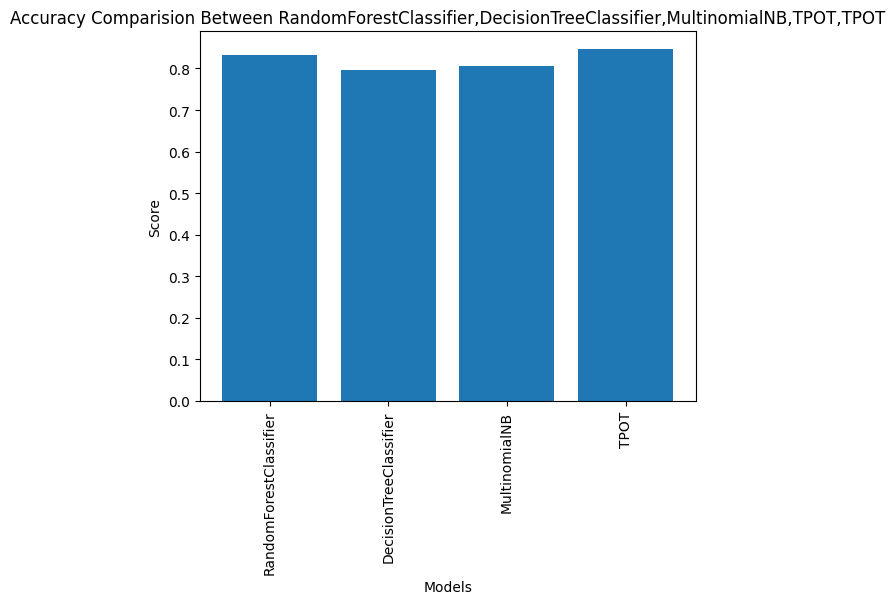

In [23]:
plt.title(f"Accuracy Comparision Between {",".join(Score['name'])}") 
plt.bar(x=Score['name'],height=Score['Score'])
plt.xticks(rotation=90)
plt.xlabel('Models')
plt.ylabel("Score")
plt.show()


In [24]:
Comment={1:"Postive Feedback Thank you so much",
         0:"Negative Feedback So sorry for this we look forward to change "}

In [25]:
test=TFID.transform([clean("Wow i had a great experience the staff and the Doctors are so Welcoming am glad i made a decision to come to this hospital")]).toarray()
test.shape
Comment[TPT.predict(test)[0]]

'Postive Feedback Thank you so much'

In [26]:

test=TFID.transform([clean("i hate this place i wont recomment for anyone not even my worst enemy")]).toarray()
test.shape
Comment[TPT.predict(test)[0]]


'Negative Feedback So sorry for this we look forward to change '

### **What ended up being your goal/solution?**

### **Does your prediction match with expectation using your designated AutoML, thus far?**

### **What were research results? Do you have results of your own yet? What are you trying to do to meet your end goal/solution?**
- handle class imbalance in datasets using SMOTE